# Primary Productivity Linear Regression Trends and Contingency Matrices

> History | Updated Apr 2025

## Overview 

This tutorial walks through two key analyses designed to evaluate and compare satellite-derived primary productivity (netPP) products:

1. **Linear Regression Trends Analysis of the Interim and Legacy Products**
Identifying trends during a timeseries for each sensor to track the agreement in netPP values between the legacy product, MODIS-AQUA, and interim products, VIIRS-SNPP and VIIRS-NOAA20 to provide validation that the interim netPP products can be reliably used for continuity in long-term productivity analyses.

2. **Contingency Table and Cohen's Kappa Comparison**
Compare trends over time between the legacy and an interim netPP products

The trend analysis follows methods outlined in Melin et al 2017, see the section 2.3 "Trend estimates and comparison of trends". Users will be able to customize the notebook for their needs by selecting a region of interest using either a Longhurst Province or a custom bounding box.

We aim to validate the reliability of interim netPP products (**VIIRS-SNPP** and **VIIRS-NOAA20**) for long-term productivity analyses in comparison to the legacy **MODIS-Aqua** product.

## Datasets Overview

We calculated the pixel-by-pixel trend coefficients and p-values for the globe for each monthly at a 9km resolution across two datasets:

1. **Temporal Trends, Primary Productivity, VIIRS NOAA-20, MODIS Aqua, Global, 9km, 2018 to 2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_trends_viirsnoaa20_and_modisaqua.graph

2. **Temporal Trends, Primary Productivity, VIIRS S-NPP, MODIS Aqua, Global, 9km, 2013 to 2022**
- Distributed via the West Coast Node ERDDAP dataset at the following link:
> https://coastwatch.pfeg.noaa.gov/wcn/erddap/griddap/netpp_trends_viirssnpp_and_modisaqua.graph

## Part 1: Linear Regression Trends Analysis

For each dataset, linear regression was applied on a per-pixel basis to compute trend coefficients (slopes) and p-values over time.

- **MODIS-Aqua**: 10-year (120-month) time series

- **VIIRS-SNPP**: 10-year (120-month) time series

- **VIIRS-NOAA20**: 5-year (60-month) time series

### Tutorial for this notebook

In this example, we are using the **MODIS-Aqua** and **VIIRS-NOAA20** dataset to generate a 5-year linear trend map for netPP.

We use the function `xr_open_ds()` to access data:

- `url`: ERDDAP server we are using is 'https://coastwatch.pfeg.noaa.gov/wcn/erddap/'

- `dataset_id`: Dataset from ERDDAP we are using is "netpp_trends_viirsnoaa20_and_modisaqua".

- `var_name`: The dataset variables. We will be using beta and pval for each sensor.

### Steps:

1. Download trend coefficients and p-values for you region on interest from the ERDDAP server for the timeseries.

2. Mask the timeseries so that only data within a shapefile is retained.

3. Visualize the spatial variability in the timeseries trend coefficients and p-values.

4. Save the image.


## Part 2: Contingency Tables and Cohen's Kappa Comparison

This section compares long-term trends in netPP between legacy (**MODIS-Aqua**) and interim (**VIIRS-SNPP**, **VIIRS-NOAA**) satellite products. 

### Tutorial for this notebook

In this tutorial, we focus on comparing **MODIS-Aqua** and **VIIRS-NOAA20** trends.

### Step 1: Long-Term Linear Trends in netPP

- **Analysis**: Linear regression applied per pixel

- **Outputs**:

    - Slope of the trend (per pixel)

    - p-value (significance)

    - Number of observations (n)

### Step 2: Constructing a Contingency Matrix 

Using the slope and significance results, each pixel is categorized into:

1. **Positive Trend:** Increasing trend  (positive slope).

2. **Negative Trend:** Decreasing trend (negative slope).

3. **No significant Trend:** Slope not sigificantly different than zero.

### Step 3: Quantifying Agreement with Cohen's Kappa

To statistically assess agreement between the two products:

- **Cohen's Kappa** is calculated from the contingency matrix.

- It accounts for agreement due to chance.

- A higher Kappa value indicated stronger agreement in trend detection between MODIS and VIIRS.


In [1]:
# Define sensor (either "snpp" or "noaa20" or "modis")
sensor1 = "modis"
sensor2 = "noaa20"

# Valid sensors list
valid_sensors = {"modis", "snpp", "noaa20"}

# Check both sensors are valid
for s in (sensor1, sensor2):
    if s not in valid_sensors:
        raise ValueError(f"The sensor '{s}' is not a valid option. Choose from: {valid_sensors}")
    
# Define time series based on sensor
def get_time_series(sensor):
    if sensor == "noaa20":
        return "2018-2022"
    elif sensor in {"snpp", "modis"}:
        return "2013-2022"
    else:
        return "Unknown timeseries"

timeseries1 = get_time_series(sensor1)
timeseries2 = get_time_series(sensor2)

# Define the trends variable for each sensor
vars1 = ["modis_beta", "modis_pval"]
vars2 = ["viirs_beta", "viirs_pval"]

# Set the url of the ERDDAP server
erddap_url = "https://coastwatch.pfeg.noaa.gov/wcn/erddap/"

# Set the ERDDAP dataset ID for MODIS and VIIRS
erddap_id = f"netpp_trends_viirs{sensor2}_and_modisaqua"

print(f"Sensor 1: {sensor1.upper()}, Time Series: {timeseries1}, Dataset ID: {erddap_id}")
print(f"Sensor 2: {sensor2.upper()}, Time Series: {timeseries2}, Dataset ID: {erddap_id}")

Sensor 1: MODIS, Time Series: 2013-2022, Dataset ID: netpp_trends_viirsnoaa20_and_modisaqua
Sensor 2: NOAA20, Time Series: 2018-2022, Dataset ID: netpp_trends_viirsnoaa20_and_modisaqua


## Shapefiles

#### Longhurst Marine Provinces  
The dataset represents the division of the world oceans into provinces as defined by Longhurst (1995; 1998; 2006). This division has been based on the prevailing role of physical forcing as a regulator of phytoplankton distribution. The Longhurst Marine Provinces dataset is available online (https://www.marineregions.org/downloads.php) and within the shapes folder associated with this repository.

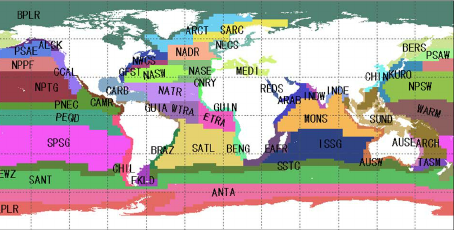


__For our example we will use the shapefile for the  "California Upwelling Coastal Province" (ProvCode: CCAL) within the Longhurst Marine Provinces classification__. 

## Resource requirements
-   **Jupyter Notebook** 

-   **Python 3** with the modules included within the *Import packages* section below

-   **Shapefile** of your area of interest
    - If you don't have shapefile, we will include some workarounds in the notebook.  
    
-   **Internet connection**  

## Import Packages

In [2]:
import matplotlib.pyplot as plt
import xarray as xr
import geopandas
import regionmask
import numpy as np
import pandas as pd
import warnings
import os
from shapely.geometry import box

warnings.filterwarnings("ignore")

## Part 1: Linear Regression Trends

### Create a few useful functions
### Function to make an Xarray dataset connection to an ERDDAP dataset

In [3]:
def xr_open_ds(e_id, e_source='https://coastwatch.pfeg.noaa.gov/wcn/erddap/', dap='griddap', var_name=None):
    """
    Open a remote ERDDAP dataset and return selected variables.

    Args:
        e_id (str): The ERDDAP dataset ID.
        e_source (str): Base URL of the ERDDAP server.
        dap (str): Data access protocol, e.g., 'griddap'.
        var_name (str or list of str, optional): Variable name(s) to extract. 
            If None, return entire dataset.

    Returns:
        xarray.Dataset or xarray.DataArray: 
            - If var_name is None: entire dataset (xarray.Dataset)
            - If var_name is a string: single variable (xarray.DataArray)
            - If var_name is a list: subset dataset (xarray.Dataset)

    Raises:
        KeyError: If any variable is not found in the dataset.
    """
    e_source = e_source.rstrip("/")
    erddap_url = '/'.join([e_source, dap, e_id])
    ds = xr.open_dataset(erddap_url)

    if var_name:
        if isinstance(var_name, str):
            if var_name in ds:
                return ds[var_name]
            else:
                raise KeyError(f"Variable '{var_name}' not found. Available: {list(ds.data_vars)}")
        elif isinstance(var_name, list):
            missing = [v for v in var_name if v not in ds]
            if missing:
                raise KeyError(f"Variables not found: {missing}. Available: {list(ds.data_vars)}")
            return ds[var_name]
        else:
            raise TypeError("var_name must be a string or list of strings")

    return ds

### Function to spatially subset an Xarray dataset using latitude and longitude

In [4]:
def subset_ds(full_ds, bnds_dic):
    """Make a spatial subset a satellite dataset.

    Args:
        full_ds (array): 2D or 3D array with lat and lon coordinate variables
        var_name (str): Name of varaible to subset.
        bnds_dic (dic): Dictionary holding lat and lon max and min values

    Returns:
        array: Xarray dataset object
    """
    # correct for reversed latitude order on a dataset
    if full_ds.latitude[0] > full_ds.latitude[-1]:
        lt_first = bnds_dic["lat_max"]
        lt_last = bnds_dic["lat_min"]
    else:
        lt_first = bnds_dic["lat_min"]
        lt_last = bnds_dic["lat_max"]

    # subset the dataset
    return full_ds.sel(
        latitude=slice(lt_first, lt_last),
        longitude=slice(bnds_dic["lon_min"], bnds_dic["lon_max"]),
    )

## Load the Longhurst Provinces shapefiles into a geopandas dataframe
In this example, we'll use the shapefile for the  **California Upwelling Coastal Province** (ProvCode: CCAL) from the Longhurst Marine Provinces classification.

- This step also isolates the California Upwelling Coastal Province.

- To inspect the shapefile's position within the dataframe, uncomment the line: 'print(shapefiles[40:45])'

In [5]:
# Create path to shapefile dataset
shape_path = os.path.join(
    "/Users/madisonrichardson/netpp/resources/Longhurst/Longhurst_world_v4_2010.shp"
)

# Create a dataframe
shapefiles = geopandas.read_file(shape_path)

# Uncomment net line to see the California Upwelling Coastal Province entry
# print(shapefiles[40:45])

# Display the available ProvCodes
available_provcodes = shapefiles["ProvCode"].unique()
print("Available ProvCodes:")
col_width = 5
for i in range(0, len(available_provcodes), col_width):
    print(" | ".join(available_provcodes[i : i + col_width]))

# Select region of interest
ProvCode = "CCAL"

# Locate the row with the ProvCode code
prov_wnt = shapefiles.loc[shapefiles["ProvCode"] == ProvCode]
prov_wnt
print(prov_wnt)

# Check if the selected ProvCode exists
if prov_wnt.empty:
    raise ValueError(
        f"Invalid ProvCode '{ProvCode}'. Please select one from the list above."
    )

Available ProvCodes:
BPLR | ARCT | SARC | NADR | GFST
NASW | NATR | WTRA | ETRA | SATL
NECS | CNRY | GUIN | GUIA | NWCS
MEDI | CARB | NASE | BRAZ | FKLD
BENG | MONS | ISSG | EAFR | REDS
ARAB | INDE | INDW | AUSW | BERS
PSAE | PSAW | KURO | NPPF | NPSW
TASM | SPSG | NPTG | PNEC | PEQD
WARM | ARCH | ALSK | CCAL | CAMR
CHIL | CHIN | SUND | AUSE | NEWZ
SSTC | SANT | ANTA | APLR
   ProvCode                                        ProvDescr  \
43     CCAL  Coastal - California Upwelling Coastal Province   

                                             geometry  
43  MULTIPOLYGON (((-110.5 24.5, -110.5 24.22013, ...  


## Create the regional mask for the California Upwelling Coastal Province
Display the region after creating it. 

<GeoAxes: >

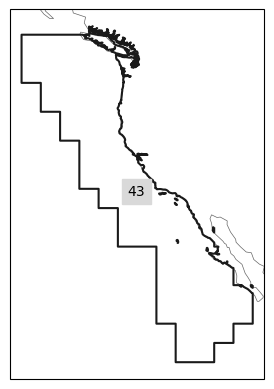

In [6]:
region = regionmask.from_geopandas(prov_wnt)
region.plot()

## Find the coordinates of the bounding box
* The bounding box is the smallest rectangle that will completely enclose the province.

* We will use the bounding box coordinates to subset the satellite data. 

In [7]:
gs_bnds = prov_wnt.bounds
gs_bnds

,minx,miny,maxx,maxy
43,-134.5,16.5,-110.5,51.383431


### To make it easier to use the subset_ds() function without a shapefile, put the bounding box coordinates in a Python dictionary.

In [8]:
geo_bnds = {}
geo_bnds["lon_min"] = gs_bnds.minx.item()
geo_bnds["lon_max"] = gs_bnds.maxx.item()
geo_bnds["lat_min"] = gs_bnds.miny.item()
geo_bnds["lat_max"] = gs_bnds.maxy.item()

## Open the dataset into a Xarray dataset object
Pass the dataset IDs and the ERDDAP server location to the xr_open_ds() function. 

* For details on xr_open_ds(), refer to the function's document string.

* **Reminder**: The erddap_id and erddap_url variables were set above.

In [9]:
ds1 = xr_open_ds(erddap_id, e_source=erddap_url, var_name=vars1)
print(f"{sensor1.upper()} dataset: {ds1}")

ds2 = xr_open_ds(erddap_id, e_source=erddap_url, var_name=vars2)
print(f"{sensor2.upper()} dataset: {ds2}")

MODIS dataset: <xarray.Dataset> Size: 75MB
Dimensions:     (latitude: 2160, longitude: 4320)
Coordinates:
  * latitude    (latitude) float64 17kB 89.96 89.88 89.79 ... -89.88 -89.96
  * longitude   (longitude) float64 35kB -180.0 -179.9 -179.8 ... 179.9 180.0
Data variables:
    modis_beta  (latitude, longitude) float32 37MB ...
    modis_pval  (latitude, longitude) float32 37MB ...
Attributes: (12/44)
    acknowledgement:           The project was supported by funding from the ...
    cdm_data_type:             Grid
    contributor:               Dale Robinson, Isaac Schroeder, Madison Richar...
    contributor_role:          project management, development, production, d...
    Conventions:               CF-1.10, COARDS, ACDD-1.3
    creator_email:             erd.data@noaa.gov
    ...                        ...
    spatialResolution:         9.28 km
    standard_name_vocabulary:  CF Standard Name Table v70
    summary:                   Temporal trends for primary productivity deriv

## Subset the satellite data
* Pass the geo_bnds variable containing bounding box coordinates to the subset_ds() function.  

__The result will be a dataset that is:__  
* Spatially subsetted to the dimensions of the bounding box corresponding to the specified sensor (either SNPP, MODIS, or NOAA20).

In [10]:
subsetted_ds1 = subset_ds(ds1, geo_bnds)
print(f"{sensor1.upper()} subset dataset: {subsetted_ds1}")

subsetted_ds2 = subset_ds(ds2, geo_bnds)
print(f"{sensor2.upper()} subset dataset: {subsetted_ds2}")

MODIS subset dataset: <xarray.Dataset> Size: 971kB
Dimensions:     (latitude: 419, longitude: 288)
Coordinates:
  * latitude    (latitude) float64 3kB 51.38 51.29 51.21 ... 16.71 16.62 16.54
  * longitude   (longitude) float64 2kB -134.5 -134.4 -134.3 ... -110.6 -110.5
Data variables:
    modis_beta  (latitude, longitude) float32 483kB ...
    modis_pval  (latitude, longitude) float32 483kB ...
Attributes: (12/44)
    acknowledgement:           The project was supported by funding from the ...
    cdm_data_type:             Grid
    contributor:               Dale Robinson, Isaac Schroeder, Madison Richar...
    contributor_role:          project management, development, production, d...
    Conventions:               CF-1.10, COARDS, ACDD-1.3
    creator_email:             erd.data@noaa.gov
    ...                        ...
    spatialResolution:         9.28 km
    standard_name_vocabulary:  CF Standard Name Table v70
    summary:                   Temporal trends for primary produc

## Determine the approximate download size

Before downloading the data, it's helpful to estimate the size of your data request to ERDDAP. 
* The data still has not been downloaded. That will happen later when an operation that needs the data is initiated. 

Depending on the installation, ERDDAP has maximum single download **limit of 2 Gigabytes**.  
* That seems large, but with satellite dataset large data volume adds up quickly.

The calculation for data download size estimate is below. 
* If the download size is nearing the single download limit, try splitting your download request into 2 or several separate requests and concatenate the data from the separate request.  

#### The request in this example is around 0.97 MB for each dataset, well within the single download limit.

In [11]:
# Set the memory size for a float32 value (4 bytes)
float_memory_size = 4

# For MODIS
download_size1 = (
    subsetted_ds1["modis_beta"].size +
    subsetted_ds1["modis_pval"].size
) * float_memory_size

# For NOAA20
download_size2 = (
    subsetted_ds2["viirs_beta"].size +
    subsetted_ds2["viirs_pval"].size
) * float_memory_size

# Print in megabytes
print(f"download_size for {sensor1.upper()}: {download_size1 / 1_000_000:.2f} MB")
print(f"download_size for {sensor2.upper()}: {download_size2 / 1_000_000:.2f} MB")

download_size for MODIS: 0.97 MB
download_size for NOAA20: 0.97 MB


## Create a mask and apply it to the data
__The result will be datasets that are:__  
* Masked to retain only the data within the shapefile. 

In [12]:
# create the mask
mask1 = region.mask(subsetted_ds1.longitude, subsetted_ds1.latitude)
mask2 = region.mask(subsetted_ds2.longitude, subsetted_ds2.latitude)

# apply mask the the satellite data
trends_ds1 = subsetted_ds1.where(mask1 == region.numbers[0])
trends_ds2 = subsetted_ds2.where(mask2 == region.numbers[0])

# set workaround flag
wa_flag = False

## Workaround if you do not have a shapefile

If you don't have a shapefile, you can instead select a rectangular area define by a latitude and a longitude range that encompasses your area of interest.  

#### Please see [Appendix B: Steps for use without a shapefile](#no_shapefile) below.

## Visualize the spatial variability of the trend coefficients and p-values for MODIS-Aqua and VIIRS-NOAA20

Plot the spatial variability of the trend coefficients for the selected Longhurst Province.
* Uncomment the last line to save the graph.

#### **Results for MODIS-Aqua and VIIRS-SNPP CCAL Region using shapefile** (workaround results will be different):

### Visualize the trends for MODIS-Aqua and VIIRS-NOAA20

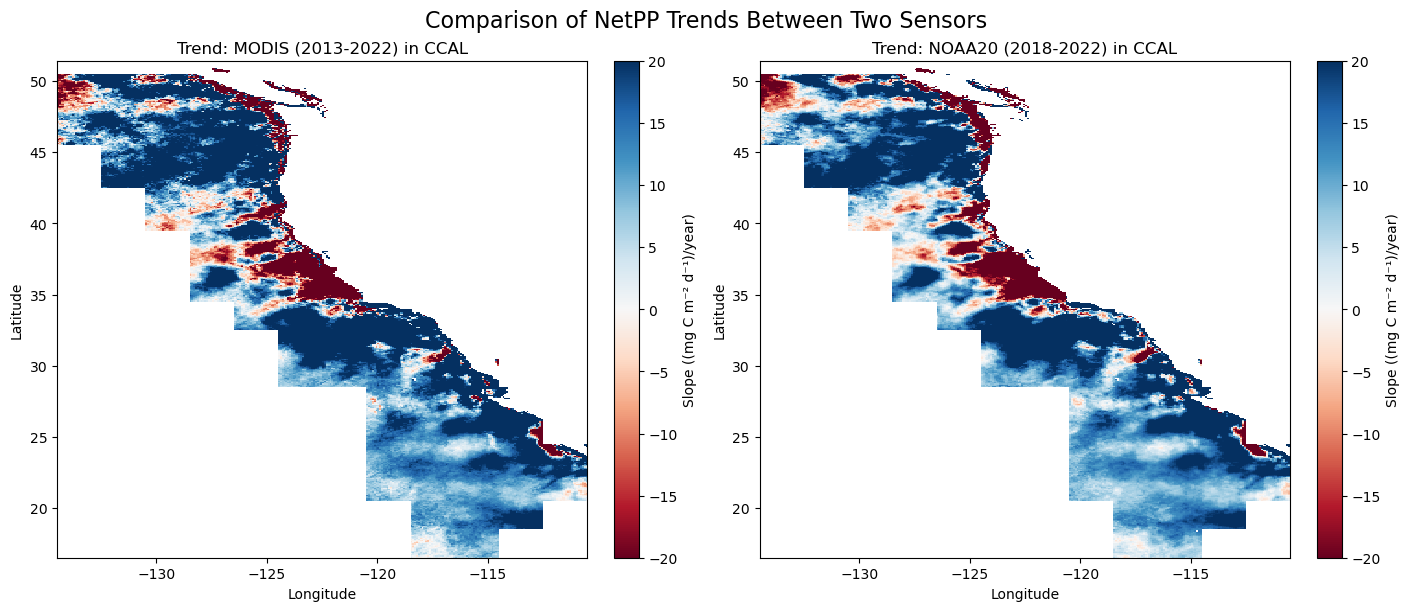

In [13]:
# Extract slope data for both datasets
slope1 = trends_ds1.modis_beta.squeeze()
slope2 = trends_ds2.viirs_beta.squeeze()

# Create subplots: 1 row, 2 columns
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), constrained_layout=True)

# Plot for sensor 1
pc1 = ax1.pcolormesh(
    trends_ds1.longitude,
    trends_ds1.latitude,
    slope1,
    vmin=-20,
    vmax=20,
    cmap="RdBu"
)
ax1.set_title(f"Trend: {sensor1.upper()} ({timeseries1}) in {ProvCode}")
ax1.set_xlabel("Longitude")
ax1.set_ylabel("Latitude")
fig.colorbar(pc1, ax=ax1, label="Slope ((mg C m⁻² d⁻¹)/year)")

# Plot for sensor 2
pc2 = ax2.pcolormesh(
    trends_ds2.longitude,
    trends_ds2.latitude,
    slope2,
    vmin=-20,
    vmax=20,
    cmap="RdBu"
)
ax2.set_title(f"Trend: {sensor2.upper()} ({timeseries2}) in {ProvCode}")
ax2.set_xlabel("Longitude")
ax2.set_ylabel("Latitude")
fig.colorbar(pc2, ax=ax2, label="Slope ((mg C m⁻² d⁻¹)/year)")

plt.suptitle("Comparison of NetPP Trends Between Two Sensors", fontsize=16)
plt.show()

# Optional: Save figure
# plt.savefig("trend_comparison.png", dpi=300)

## Appendix A: Visualize the unmasked and masked data on a map
The maps shows the full coverage of the bounding box and the masked area set by the shapefile for CCAL.

#### Visualize the unmasked and masked trends for MODIS-Aqua

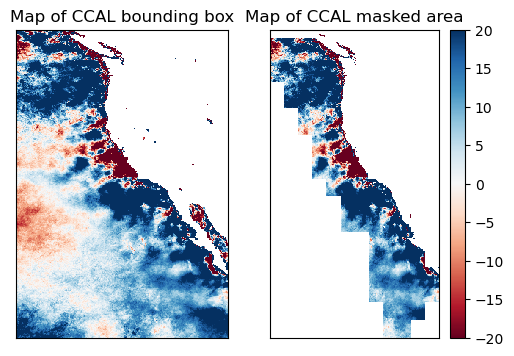

In [14]:
# if wa_flag is True, set 'plot_ds' to 'trends_ds', if not use 'subsetted_ds'
if wa_flag:
    plot_ds = trends_ds1
else:
    plot_ds = subsetted_ds1

# create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# customize the first subplot (ax1)
ax1.set_title(f"Map of CCAL bounding box")
ax1.set_yticks([])
ax1.set_xticks([])

# plot data on ax1 where plot_ds = subsetted_ds and reverse latitude order for correct orientation
ax1.pcolormesh(
    plot_ds["modis_beta"]
    .reindex(latitude=list(reversed(plot_ds.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# customize the second subplot (ax2)
ax2.set_title(f"Map of CCAL masked area")
ax2.set_yticks([])
ax2.set_xticks([])

# plot data on ax2 where plot_ds = trends_ds and reverse latitude order for correct orientation
pc = ax2.pcolormesh(
    trends_ds1["modis_beta"]
    .reindex(latitude=list(reversed(trends_ds1.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# add a color bar to the figure
fig.colorbar(pc)

#### Visualize the unmasked and masked trends for VIIRS-NOAA20

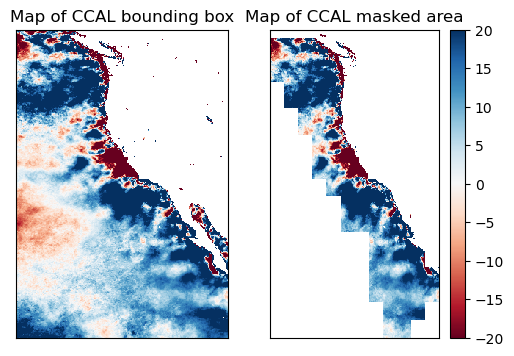

In [15]:
# if wa_flag is True, set 'plot_ds' to 'trends_ds', if not use 'subsetted_ds'
if wa_flag:
    plot_ds = trends_ds2
else:
    plot_ds = subsetted_ds2

# create the figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(6, 4))

# customize the first subplot (ax1)
ax1.set_title(f"Map of CCAL bounding box")
ax1.set_yticks([])
ax1.set_xticks([])

# plot data on ax1 where plot_ds = subsetted_ds and reverse latitude order for correct orientation
ax1.pcolormesh(
    plot_ds["viirs_beta"]
    .reindex(latitude=list(reversed(plot_ds.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# customize the second subplot (ax2)
ax2.set_title(f"Map of CCAL masked area")
ax2.set_yticks([])
ax2.set_xticks([])

# plot data on ax2 where plot_ds = trends_ds and reverse latitude order for correct orientation
pc = ax2.pcolormesh(
    trends_ds2["viirs_beta"]
    .reindex(latitude=list(reversed(trends_ds2.latitude))),
    vmin=-20,
    vmax=20,
    cmap="RdBu",
)

# add a color bar to the figure
fig.colorbar(pc)

## Part 2: Compare Products with Contingency Tables

### Function for finding common grid points among the two sensors

In [16]:
def get_common_points(source_list, beta_data_list, pval_data_list):
    """
    Extract common grid points with valid data between
    two sources.

    This function identifies grid points where both datasets
    contain valid data, reshapes 2D beta and p-value arrays
    into 1D vectors for comparison, and returns the beta values,
    p-values, and count of common points. Zeros in beta and
    p-values are replaced with small values (0.00001) to
    prevent issues during processing.

    Args:
        source_list (list): 
            A list of source names to compare (e.g., 'modis' or 'noaa20')
        beta_data_list (list):
            A list of 2D arrays (one per source) containing beta values
            (e.g., slope or trend data) for each grid point.
        pval_data_list (list):
            A list of 2D arrays (one per source) containing p-values
            for the statistical significance of the beta values.

    Returns:
        tuple: 
            beta_common (list):
                A list of 1D arrays, where each array contains
                beta values for grid points that are valid and
                common between the two datasets. The first array
                corresponds to 'source_list[0]', and the second
                corresponds to 'source_list[1]'.
            pval_common (list):
                A list of 1D arrays, where each array contains
                p-values for grid points that are valid and
                common between the two datasets. The order
                corresponds to 'source_list'.
            num_common (int):
                The total number of grid points that are common
                and have valid data in both datasets.
    """
    # Find the common grid points with trends
    beta_re_list = []  # reshaped beta values
    pval_re_list = []  # reshaped p-values
    ind_re_list = []  # indices of non-missing values

    for i in range(len(source_list)):
        # Reshape 2D arrays into 1D vectors
        ny, nx = beta_data_list[i].shape
        beta_re = np.reshape(beta_data_list[i].data, ny*nx)
        pval_re = np.reshape(pval_data_list[i].data, ny*nx)

        # Find indices of finites values (non-NaN)
        ind_re = np.isfinite(beta_re).nonzero()[0]

        # Replace zeros with small values to avoid issues
        trend_indices_1 = np.where(beta_re == 0.0)
        beta_re[trend_indices_1] = 0.00001
        pval_re[trend_indices_1] = 0.00001

        # Append results to lists
        beta_re_list.append(beta_re)
        pval_re_list.append(pval_re)
        ind_re_list.append(ind_re)

    # Find common indices between the two datasets
    common_indices_12 = np.isin(
        ind_re_list[0],
        ind_re_list[1]
    )  # common in source1 and source2
    common_indices_21 = np.isin(
        ind_re_list[1],
        ind_re_list[0]
    )  # common in source2 and source1

    # Extract beta and p-value data for the common grid points
    beta_common = [
        beta_re_list[0][ind_re_list[0]][common_indices_12],
        beta_re_list[1][ind_re_list[1]][common_indices_21]
    ]
    pval_common = [
        pval_re_list[0][ind_re_list[0]][common_indices_12],
        pval_re_list[1][ind_re_list[1]][common_indices_21]
    ]

    # Number of common points
    num_common = len(beta_common[0])

    return beta_common, pval_common, num_common

### Function for 2x2 Contingency Table

In [17]:
def make_2x2_contingency_table(beta_common, num_common, source_list):
    """
    Create a 2x2 contingency table comparing
    trends between two sources.

    This function compares the signs of trends (beta values) between two
    sources for common grid points and generates a 2x2 contingency table.
    The table represents the percentage of grid points that fall
    into each combination of positive and negative trends for the
    two sources.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values
            for the grid points that are common between the
            two data sources. 'beta_common[0]' corresponds
            to the first source in 'source_list'. 
            'beta_common[1]' corresponds to the first
            source in 'source_list'. 
        num_common (int):
            The total number of grid points that are
            common between the two sources.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']).
            The first name corresponds to 'beta_common[0]', and
            the second corresponds to 'beta_common[1]'.

    Returns:
        tuple: A tuple containing the following:
            col_labels_2x2 (list): 
                Column labels for the contingency table
                indicating the trend direction for the first source (e.g.,
                `['MODIS $\\beta>=0$', 'MODIS $\\beta<0$']`).
            row_label_2x2 (list):
                Row labels for the contingency table
                indicating the trend direction for the second source (e.g.,
                `['NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']`).
            contingency_table_2x2 (numpy.ndarray):
                A 2x2 matrix representing the contingency table.
                Each cell contains the percentage of grid points
                that fall into the corresponding combination of trend
                directions.
            contingency_df_2x2 (pandas.DataFrame):
                A DataFrame representation of the contingency
                table with labeled rows and columns for easier
                visualization and interpretation.

    Contingency Table Structure:
        The table has two rows and two columns:
            Rows represent the trend direction for the second source
            (`source_list[1]`).
            Columns represent the trend direction for the first source
            (`source_list[0]`).
            Each cell represents the percentage of grid points where the
            specified trend combination is observed.

    Notes:
        Positive trends are identified as beta values greater than or equal
        to 0, and negative trends are identified as beta values less than 0.
        Percentages in the contingency table are normalized to the total
        number of common grid points (`num_common`).
        The function ensures compatibility with numpy arrays for efficient
        computation.
    """
    # Define the labels for a table
    operator_lbl = [r'$\beta>0$', r'$\beta<0$']
    col_labels_2x2 = []
    row_label_2x2 = []
    for i in range(2):
        col_labels_2x2.append(
            '{} {}'.format(source_list[0].upper(),
                           operator_lbl[i])
        )
        row_label_2x2.append(
            '{} {}'.format(source_list[1].upper(),
                           operator_lbl[i])
        )

    # Define trend sign combinations for the contingency table
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    # Intialize the table as a vector
    table22_vec = np.zeros(len(trend_sign_combos))

    # Intialize the table as a vector
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]
    table22_vec = np.zeros(len(trend_sign_combos))
    for i in range(len(trend_sign_combos)):
        # Identify points with the specified trends
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*beta_common[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*beta_common[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table22_vec[i] = 100*num1/num_common

    # Convert vector to 2x2 matrix
    contingency_table_2x2 = table22_vec.reshape(2, 2)

    # Create a Pandas DataFrame from the 2x2 table
    contingency_df_2x2 = pd.DataFrame(
        contingency_table_2x2, columns=col_labels_2x2
    )
    contingency_df_2x2 = contingency_df_2x2.set_index(
        np.array(row_label_2x2)
    )

    return (
        col_labels_2x2,
        row_label_2x2,
        contingency_table_2x2, 
        contingency_df_2x2
    )

### Function for 3x3 Contingency Table

In [18]:
def make_3x3_contingency_table(
        beta_common,
        pval_common,
        num_common,
        source_list,
        alpha = 0.05
):
    """
    Create a 3x3 contingency table comparing trends and
    significance levels between two sources.

    This function analyzes the relationship between
    trends (beta values) and their statistical significance
    (p-values) for two datasets. It calculates percentages
    of grid points falling into combinations of non-significant 
    (n.s.), positive trends (β ≥ 0), and negative trends (β < 0) 
    for each source, with significance determined by a
    threshold `alpha`.

    Args:
        beta_common (list):
            A list containing two 1D arrays of beta values (e.g., trends or 
            slopes) for the grid points common between the two data sources.
            `beta_common[0]`: Beta values for the first source in `source_list`.
            `beta_common[1]`: Beta values for the second source in `source_list`.
        pval_common (list):
            A list containing two 1D arrays of p-values for the grid points 
            common between the two data sources.
            `pval_common[0]`: P-values for the first source in `source_list`.
            `pval_common[1]`: P-values for the second source in `source_list`.
        num_common (int):
            The total number of grid points common to both sources.
            This is used as the denominator to calculate percentages.
        source_list (list):
            A list of source names (e.g., ['modis', 'noaa20']). The first name 
            corresponds to `beta_common[0]` and `pval_common[0]`, and the second 
            corresponds to `beta_common[1]` and `pval_common[1]`.
        alpha (float):
            The significance threshold for p-values (e.g., 0.05).
            Grid points with p-values below this threshold are
            considered statistically significant.

    Returns:
        tuple: A tuple containing the following:
            col_labels_3x3 (list):
                Column labels for the contingency table, 
                indicating the trend categories for the first source 
                e.g., ['MODIS n.s.', 'MODIS $\\beta>=0$', 'MODIS $\\beta<0$']).
            row_label_3x3 (list): 
                Row labels for the contingency table, 
                indicating the trend categories for the second source 
                (e.g., ['NOAA20 n.s.', 'NOAA20 $\\beta>=0$', 'NOAA20 $\\beta<0$']).
            contingency_table_3x3 (numpy.ndarray):
                A 3x3 matrix representing the contingency table. Each cell
                contains the percentage of grid points in the corresponding
                combination of trend categories.
            contingency_df_3x3 (pandas.DataFrame): 
                A DataFrame representation of the 3x3 contingency table with
                labeled rows and columns, providing easier visualization and
                interpretation.

    Contingency Table Categories:
        Rows and columns represent the trend categories for the two sources:
            Non-significant (n.s.): 
                Grid points with p-values ≥ alpha.
            Positive trend (β ≥ 0): 
                Grid points with significant trends and 
                positive beta values.
            Negative trend (β < 0): 
                Grid points with significant trends and 
                negative beta values.
        Each cell represents the percentage of grid points that fall into 
        the combination of trend categories for the two sources.

     Notes:
        Percentages are calculated relative to the total number of common 
        grid points (`num_common`). This function assumes that `beta_common`
        and `pval_common` are aligned such that their indices correspond
        to the same grid points in both sources. Positive and negative
        trends are determined only for significant grid points
        (p-values < alpha).
    """

    # Initialize the 3x3 table
    contingency_table_3x3 = np.zeros([3, 3])

    # Define and create labels for the 3x3 matrix
    operator_lbl = ['n.s.', r'$\beta>0$', r'$\beta<0$']
    col_labels_3x3 = []
    row_label_3x3 = []
    for i in range(3):
        col_labels_3x3.append(
            '{} {}'.format(source_list[0].upper(), operator_lbl[i])
        )
        row_label_3x3.append(
            '{} {}'.format(source_list[1].upper(), operator_lbl[i])
        )

    # Calculate values for the first row/column in non-significant cases (ns)
    ns_indices_1 = np.where(pval_common[0] >= alpha)[0]
    ns_indices_2 = np.where(pval_common[1] >= alpha)[0]
    common_indices_ns = np.isin(ns_indices_1, ns_indices_2).nonzero()[0]
    contingency_table_3x3[0, 0] = 100*len(common_indices_ns)/num_common

    # Calculate when beta1 is ns and beta2 is sig (pos/neg trends)
    # Identify indices in the beta2 where trends are sig
    sig_indices_2 = np.where(pval_common[1][ns_indices_1] < alpha)[0]

    # Extract sig beta values from beta2
    beta2_sig = beta_common[1][ns_indices_1][sig_indices_2]

    # Separate sig beta2 values into pos and neg trends
    in2_sig_pos = np.where(beta2_sig >= 0)[0]
    in2_sig_neg = np.where(beta2_sig < 0)[0]

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate the percentage of positive and negative trends for beta2
    contingency_table_3x3[1, 0] = 100*len(in2_sig_pos)/num_common  # % of pos trends when beta1 is ns
    contingency_table_3x3[2, 0] = 100*len(in2_sig_neg)/num_common  # % of neg trends when beta1 is ns

    # Calculate when beta2 is ns and beta1 is sig (pos/neg trends)
    # Identify indices in the beta1 where trends are sig
    sig_indices_1 = np.where(pval_common[0][ns_indices_2] < alpha)[0]

    # Extract the sig beta1 values
    beta1_sig = beta_common[0][ns_indices_2][sig_indices_1]

    # Separate sig beta1 values into pos/neg trends
    trend_indices_2_sig_pos = np.where(beta1_sig >= 0)[0]
    trend_indices_2_sig_neg = np.where(beta1_sig < 0)[0]

    # Calculate the percentage of pos trends for beta1
    contingency_table_3x3[0, 1] = 100*len(trend_indices_2_sig_pos)/num_common  # % of pos trends when beta2 is ns
    contingency_table_3x3[0, 2] = 100*len(trend_indices_2_sig_neg)/num_common  # % of neg trends when beta2 is ns

    # Calculate when both beta1 and beta2 have sig trends
    # Identify sig trends for both datasets
    sig_indices_1 = np.where(pval_common[0] < alpha)[0]
    sig_indices_2 = np.where(pval_common[1] < alpha)[0]

    # Find common sig trends for both datsets
    common_indices_sig1 = np.isin(sig_indices_1, sig_indices_2).nonzero()[0]
    common_indices_sig2 = np.isin(sig_indices_2, sig_indices_1).nonzero()[0]

    # Extract beta values for common sig points
    reshaped_data = [
        beta_common[0][sig_indices_1][common_indices_sig1],
        beta_common[1][sig_indices_2][common_indices_sig2]
    ]

    # Define sign combinations for trends in both datasets
    trend_sign_combos = [[1, 1], [-1, 1], [1, -1], [-1, -1]]

    # Initialize a vector to store the percentages for each combo
    table33_vec = np.zeros(len(trend_sign_combos))

    # Calculate the percentage of grid points for each trend combo
    for i in range(len(trend_sign_combos)):
        sign_combo = trend_sign_combos[i]
        trend_indices_1 = np.where(sign_combo[0]*reshaped_data[0] > 0)[0]
        trend_indices_2 = np.where(sign_combo[1]*reshaped_data[1] > 0)[0]
        common_indices_sig1 = np.isin(trend_indices_1, trend_indices_2)
        num1 = len(common_indices_sig1.nonzero()[0])
        table33_vec[i] = 100*num1/num_common

    # Populate the lower-right 4 cells
    contingency_table_3x3[1:, 1:] = np.reshape(table33_vec, [2, 2])

    # Create a Pandas DataFrame from the 3x3 table
    contingency_df_3x3 = pd.DataFrame(
        contingency_table_3x3,
        columns=col_labels_3x3
    )
    contingency_df_3x3 = contingency_df_3x3.set_index(np.array(row_label_3x3))
    contingency_df_3x3 = np.round(contingency_df_3x3*100)/100

    return (
        col_labels_3x3,
        row_label_3x3,
        contingency_table_3x3,
        contingency_df_3x3
    )

### Function for finding Cohen's Kappa

In [19]:
def find_kappa(contingency_table):
    """
    Calculate Cohen's Kappa for a given contingency table.

    Cohen's Kappa is a statistical to quantify the level
    of agreement between the two NetPP products. It
    provides a summary metric on a scale of 0 to 1, where 1
    indicates perfect agreement and 0 indicates no agreement.

    Args:
        contingency_table (numpy.ndarray):
            A square matrix (e.g., 2x2, 3x3) representing the contingency 
            table. Each cell contains the count or percentage of observations 
            in the corresponding category combination. 
            - Rows typically represent categories from one source.
            - Columns represent categories from the second source.

    Returns:
        float:
            Cohen's Kappa statistic, ranging from -1 to 1:
                A value of 1 indicates perfect agreement.
                A value of 0 indicates agreement no better than chance.
                A negative value indicates agreement worse than chance.

    Formula:
        Cohen's Kappa is calculated as:

            kappa = (observed_agreement - expected_agreement)(1 - expected_agreement)
            
                Where:
                    The observed proportion of agreement is the sum of the 
                    diagonal elements divided by the total.
                    The expected proportion of agreement by chance, 
                    calculated from row and column marginal totals.

     Notes:
        The function assumes the input contingency table contains either 
        counts or percentages. For percentages, the table should sum to 100; 
        for counts, the table should sum to the total number of observations.
        Kappa values close to 1 indicate strong agreement, while values near 
        or below 0 indicate poor agreement.
    """

    # Calculate row and column sums
    row_sum = np.sum(contingency_table, axis=1)
    clmn_sum = np.sum(contingency_table, axis=0)

    # Calculate the trace
    trc_sum = np.trace(contingency_table)

    # Calculate the overall sum (total number of grid points)
    overall_sum = np.sum(row_sum)

    # Calculate expected freqs for agreement by chance
    expected_freqs = row_sum * clmn_sum / overall_sum
    expected_freqs_sum = np.sum(expected_freqs)

    # Compute kappa
    kappa = (trc_sum - expected_freqs_sum) / (overall_sum - expected_freqs_sum)

    return kappa

### Function for plotting contingency tables

In [20]:
def plot_contingency_table(
        table,
        column_labels,
        row_labels,
        title,
        kappa,
        cmap="Blues"
):
    """
    Plot a contingency table as a heatmap with
    percentage annotations and Cohen's Kappa.

    Args:
        table (numpy.ndarray): A 2D array representing the contingency table 
        values (e.g., percentages).
        column_labels (list): List of labels for the table's columns.
        row_labels (list): List of labels for the table's rows.
        title (str): Title for the heatmap plot.
        kappa (float): Cohen's Kappa statistic value to annotate on the plot.
        cmap (str, optional): Colormap for the heatmap. Defaults to "Blues".

    Returns:
        Displays the heatmap plot with annotations and kappa value.
    """

    fig, ax = plt.subplots(figsize=(8, 6))

    # Plot heatmap
    heatmap = ax.imshow(table, cmap=cmap, aspect='auto')

    # Add colorbar
    cbar = plt.colorbar(heatmap, ax=ax)
    cbar.set_label("Percentage (%)", rotation=270, labelpad=15)

    # Set axis labels
    ax.set_xticks(range(len(column_labels)))
    ax.set_xticklabels(column_labels, rotation=45, ha="right", fontsize=12)
    ax.set_yticks(range(len(row_labels)))
    ax.set_yticklabels(row_labels, fontsize=12)

    # Add text annotations with adaptive color
    for i in range(table.shape[0]):
        for j in range(table.shape[1]):
            value = table[i, j]
            intensity = heatmap.get_array()[i, j]
            text_color = "white" if intensity > 50 else "black"
            ax.text(
                j,
                i,
                f"{value:.1f}",
                ha="center",
                va="center",
                color=text_color,
                fontsize=14
            )

    # Set the title
    ax.set_title(title, fontsize=14, pad=20)

    # Add Cohen's Kappa as a text annotation
    fig.text(
        0.5,
        0.02,
        f"Cohen's Kappa = {kappa:.2f}",
        ha="center",
        va="center",
        fontsize=14,
        color="blue"
    )

    # Adjust layout
    plt.tight_layout(rect=[0, 0.05, 1, 1])

    # Show the plot
    plt.show()

## Extract latitude and longitude for region of interest

In [21]:
region_lons = ds1['longitude'].sel(
    longitude=slice(geo_bnds["lon_min"], geo_bnds["lon_max"])
).data

region_lats = ds1['latitude'].sel(
    latitude=slice(geo_bnds["lat_max"], geo_bnds["lat_min"])
).data

## Mask the data based on region

* Mask the trend data for both source types

* Apply the mask to the DataArray using the 'where' function

* The 'where' function sets any gridpoints outside the mask to a NaN value

In [22]:
source_list = [ds1, ds2]
source_names = [sensor1, sensor2]

beta_data_list = []
pval_data_list = []

for i, ds in enumerate(source_list):
    sensor = source_names[i]

    # All VIIRS sensors use 'viirs_*', MODIS uses 'modis_*'
    if sensor == "modis":
        prefix = "modis"
    else:  # for both "snpp" and "noaa20"
        prefix = "viirs"

    beta_var = f"{prefix}_beta"
    pval_var = f"{prefix}_pval"

    # Extract and spatially subset beta and pval using geo_bnds
    beta_data = (
        ds[beta_var]
        .squeeze()
        .sel(
            latitude=slice(geo_bnds["lat_max"], geo_bnds["lat_min"]),
            longitude=slice(geo_bnds["lon_min"], geo_bnds["lon_max"])
        )
    )
    pval_data = (
        ds[pval_var]
        .squeeze()
        .sel(
            latitude=slice(geo_bnds["lat_max"], geo_bnds["lat_min"]),
            longitude=slice(geo_bnds["lon_min"], geo_bnds["lon_max"])
        )
    )

    # Create the region mask using the subsetted lat/lon
    mask = region.mask(beta_data.longitude, beta_data.latitude)

    # Apply the region mask
    beta_data_mask = beta_data.where(mask == region.numbers[0])
    pval_data_mask = pval_data.where(mask == region.numbers[0])

    # Append to lists
    beta_data_list.append(beta_data_mask)
    pval_data_list.append(pval_data_mask)

## Find common grid points that have trend values

Using *get_common_points*, extract common data points across the datasets.

* Prints the selected province (ProvCode) and bounding region coordinates (geo_bnds).

In [23]:
beta_common, pval_common, num_common = get_common_points(
    source_list=source_names,
    beta_data_list=beta_data_list,
    pval_data_list=pval_data_list
)

## Construct Contingency Tables and Compute Cohen's Kappa

To assess the agreement between legacy MODIS-Aqua and interim VIIRS-NOAA20 products, we construct **2x2** and **3x3 contingency tables** and compute **Cohen's Kappa**.

The **2x2 contingency table** categorizes pixels based on whether both datasets exhibit **positive ($\beta>=0$) or negative ($\beta<0$) trends**.

The **3x3 table** introduces a **non-significant trend (n.s.)** category, which accounts for cases where trends do not meet statistical significance thresholds.

**Cohen's Kappa** quantifies the agreement between datasets, and ranges from **0 (no agreement)** to **1 (perfect agreement)**.

In [24]:
# 2x2 contingency matrix
(
    col_labels_2x2,
    row_label_2x2,
    contingency_table_2x2,
    contingency_df_2x2
) = make_2x2_contingency_table(
    beta_common,
    num_common,
    source_names
)

print('Contingency table 2 x 2:\n')
print(contingency_df_2x2)

# 3x3 contingency matrix
(
    col_labels_3x3,
    row_label_3x3,
    contingency_table_3x3,
    contingency_df_3x3
) = make_3x3_contingency_table(
    beta_common,
    pval_common,
    num_common,
    source_names
)

print('Contigency table 3 x 3:\n')
print(contingency_df_3x3)

Contingency table 2 x 2:

                  MODIS $\beta>0$  MODIS $\beta<0$
NOAA20 $\beta>0$        79.947216         2.734231
NOAA20 $\beta<0$         3.660596        13.657957
Contigency table 3 x 3:

                  MODIS n.s.  MODIS $\beta>0$  MODIS $\beta<0$
NOAA20 n.s.            48.38             3.37             0.26
NOAA20 $\beta>0$        6.22            39.99             0.00
NOAA20 $\beta<0$        0.91             0.00             0.87


## Calculate Cohen's Kappa

In [25]:
kappa_2x2 = find_kappa(contingency_table_2x2)
kappa_3x3 = find_kappa(contingency_table_3x3)
print(f"2x2 Kappa: {kappa_2x2:.2f}")
print(f"3x3 Kappa: {kappa_3x3:.2f}")

2x2 Kappa: 0.77
3x3 Kappa: 0.79


## Create a Figure for Both Tables

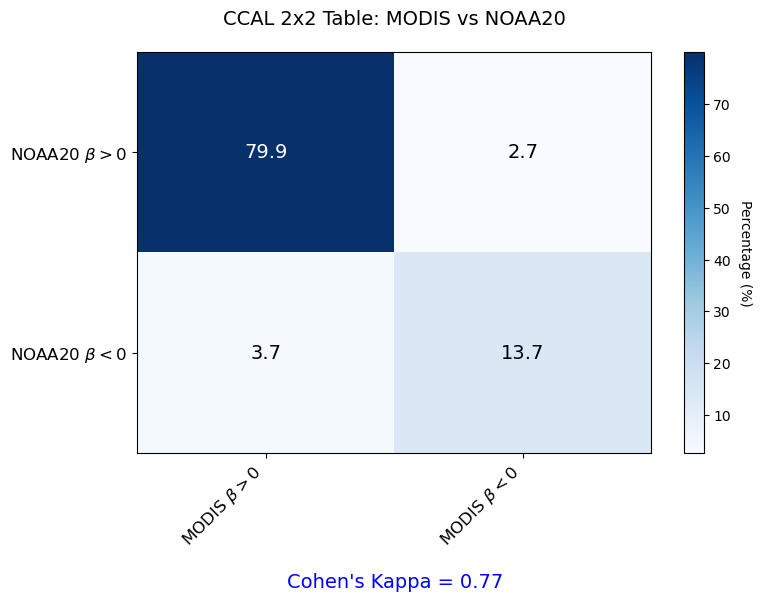

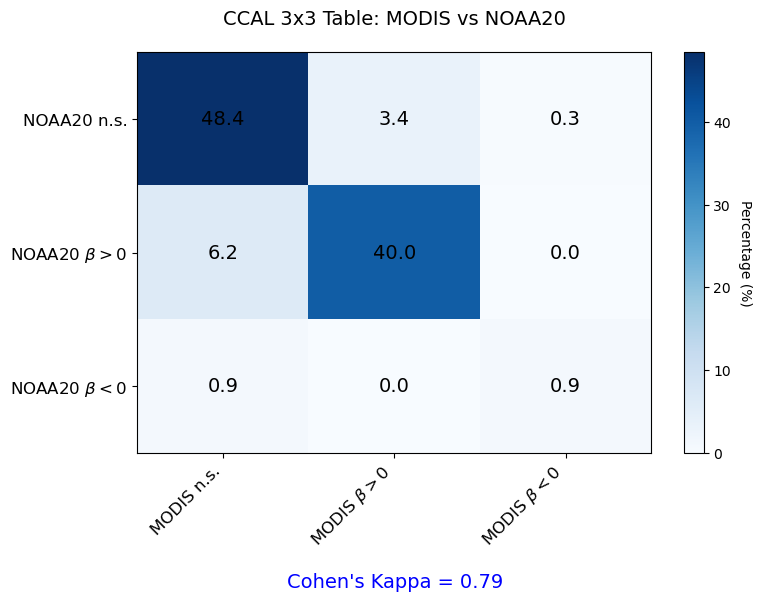

In [26]:
# Plot 2x2 contingency table
plot_contingency_table(
    contingency_table_2x2,
    col_labels_2x2,
    row_label_2x2,
    title=f"{ProvCode} 2x2 Table: {sensor1.upper()} vs {sensor2.upper()}",
    kappa=kappa_2x2
)

# Plot 3x3 contingency table
plot_contingency_table(
    contingency_table_3x3,
    col_labels_3x3,
    row_label_3x3,
    title=f"{ProvCode} 3x3 Table: {sensor1.upper()} vs {sensor2.upper()}",
    kappa=kappa_3x3
)


## Appendix B: Steps for use without a shapefile
<a id='no_shapefile'></a>
### __Do not run this code if you have used a shapefile above!__
Use this method in place of cells tagged "Shapefile method".  

If you don't have a shapefile, you can just select a rectangular area that encompasses your area of interest. The area is define by a the maximum and minimum values of a latitude and a longitude range.   

__Steps__:  
1. Load the geo_bnds dictionary with the minimum and maximum values for latitude and longitude the area of interest. 
* An area off the Oregon coast is used the example below:

    * Latitude range: 42.0&deg; to 46.0&deg; N

    * Longitude range: -128.0&deg; to -124&deg; E
2. Proceed through the data download and subsetting steps as listed below:

* Note that the masking steps have been omitted.

In [27]:
geo_bnds = {}
geo_bnds["lon_min"] = -128.0
geo_bnds["lon_max"] = -124.0
geo_bnds["lat_min"] = 42.0
geo_bnds["lat_max"] = 46.0

# Change this code "subsetted_ds = subset_ds(ds, erddap_var, geo_bnds)" to:
trends_ds1 = subset_ds(ds1, geo_bnds)
trends_ds2 = subset_ds(ds2, geo_bnds)

# set workaround flag
wa_flag = True

# Omit create the mask
# mask = region.mask(subsetted_ds.longitude, subsetted_ds.latitude)

# Omit apply mask the the satellite data
# trends_ds = subsetted_ds.where(mask == region.numbers[0])